<a href="https://colab.research.google.com/github/kennedy-kitoko/first-repository/blob/main/ROBOT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
# Installation des bibliothèques principales
!pip install ultralytics roboflow supervision opencv-python matplotlib seaborn
!pip install wandb  # Pour le tracking des expériences (optionnel)

# Vérification des versions
import ultralytics
print(f"Ultralytics version: {ultralytics.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.8/85.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.5/181.5 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 87.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56

In [ ]:
import os
import cv2
import yaml
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import Image, display
import warnings
warnings.filterwarnings('ignore')

# Configuration pour la reproductibilité
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Configuration d'affichage
plt.style.use('default')
sns.set_palette("husl")

print("✅ Configuration terminée")

✅ Configuration terminée


In [ ]:
import torch
from ultralytics import YOLO

# Vérification GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🖥️  Device utilisé: {device}")

if device == 'cuda':
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 Mémoire GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  CPU uniquement - L'entraînement sera plus lent")

# Test de YOLO
try:
    model = YOLO('yolo11n.pt')  # Test avec un modèle léger
    print("✅ YOLO fonctionnel")
    del model  # Libération mémoire
except Exception as e:
    print(f"❌ Erreur YOLO: {e}")

🖥️  Device utilisé: cpu
⚠️  CPU uniquement - L'entraînement sera plus lent


100%|██████████| 5.35M/5.35M [00:00<00:00, 66.4MB/s]


✅ YOLO fonctionnel


In [ ]:
from roboflow import Roboflow

# Configuration Roboflow
rf = Roboflow(api_key="NqjtCN1BkDxTg2u1jXzs")  # Remplacez par votre clé

# Téléchargement du dataset (exemple: détection de mauvaises herbes)
project = rf.workspace("augmented-startups").project("weeds-nxe1w")
version = project.version(3)

# Téléchargement au format YOLOv12
print("📥 Téléchargement du dataset...")
dataset = version.download("yolov11")  # YOLOv11 format compatible avec v12

print(f"✅ Dataset téléchargé dans: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...
📥 Téléchargement du dataset...



Extracting Dataset Version Zip to Weeds-3 in yolov11:: 100%|██████████| 8418/8418 [00:07<00:00, 1163.01it/s]


✅ Dataset téléchargé dans: /content/Weeds-3


In [ ]:
# Variables globales
DATASET_PATH = dataset.location
DATA_YAML_PATH = f"{DATASET_PATH}/data.yaml"

print(f"📁 Structure du dataset:")
print(f"   📂 {DATASET_PATH}")

# Exploration des dossiers
for split in ['train', 'valid', 'test']:
    images_path = f"{DATASET_PATH}/{split}/images"
    labels_path = f"{DATASET_PATH}/{split}/labels"

    if os.path.exists(images_path):
        img_count = len([f for f in os.listdir(images_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        lbl_count = len([f for f in os.listdir(labels_path) if f.endswith('.txt')]) if os.path.exists(labels_path) else 0

        print(f"   📊 {split.capitalize()}: {img_count} images, {lbl_count} annotations")
    else:
        print(f"   ❌ Dossier {split} manquant")

📁 Structure du dataset:
   📂 /content/Weeds-3
   📊 Train: 3664 images, 3664 annotations
   📊 Valid: 359 images, 359 annotations
   📊 Test: 180 images, 180 annotations


In [ ]:
# Lecture du fichier data.yaml original
with open(DATA_YAML_PATH, 'r') as f:
    config_content = f.read()

print("📄 Configuration originale:")
print(config_content)
print("\n" + "="*50)

# Correction des chemins pour compatibilité YOLO
corrected_config = f"""# Dataset configuration
# Chemins relatifs pour portabilité
train: train/images
val: valid/images
test: test/images

# Informations sur les classes
nc: 1  # Nombre de classes
names: ['weed']  # Noms des classes

# Métadonnées
path: {DATASET_PATH}  # Chemin racine du dataset
"""

# Sauvegarde de la configuration corrigée
with open(DATA_YAML_PATH, 'w') as f:
    f.write(corrected_config)

print("✅ Fichier data.yaml corrigé:")
print(corrected_config)

📄 Configuration originale:
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['Weeds']

roboflow:
  workspace: augmented-startups
  project: weeds-nxe1w
  version: 3
  license: CC BY 4.0
  url: https://universe.roboflow.com/augmented-startups/weeds-nxe1w/dataset/3

✅ Fichier data.yaml corrigé:
# Dataset configuration
# Chemins relatifs pour portabilité
train: train/images
val: valid/images
test: test/images

# Informations sur les classes
nc: 1  # Nombre de classes
names: ['weed']  # Noms des classes

# Métadonnées
path: /content/Weeds-3  # Chemin racine du dataset



In [ ]:
import supervision as sv

# Chargement du dataset avec Supervision
ds = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{DATASET_PATH}/train/images",
    annotations_directory_path=f"{DATASET_PATH}/train/labels",
    data_yaml_path=DATA_YAML_PATH
)

print(f"🔍 Analyse du dataset:")
print(f"   📊 Nombre total d'images: {len(ds)}")
print(f"   🏷️  Classes disponibles: {ds.classes}")

# Statistiques des annotations
total_annotations = 0
class_distribution = {}

for i, (_, _, annotations) in enumerate(ds):
    if annotations.class_id is not None:
        total_annotations += len(annotations.class_id)
        for class_id in annotations.class_id:
            class_name = ds.classes[class_id]
            class_distribution[class_name] = class_distribution.get(class_name, 0) + 1

print(f"   📈 Total annotations: {total_annotations}")
print(f"   📊 Distribution par classe: {class_distribution}")

🔍 Analyse du dataset:
   📊 Nombre total d'images: 3664
   🏷️  Classes disponibles: ['weed']
   📈 Total annotations: 9983
   📊 Distribution par classe: {'weed': 9983}


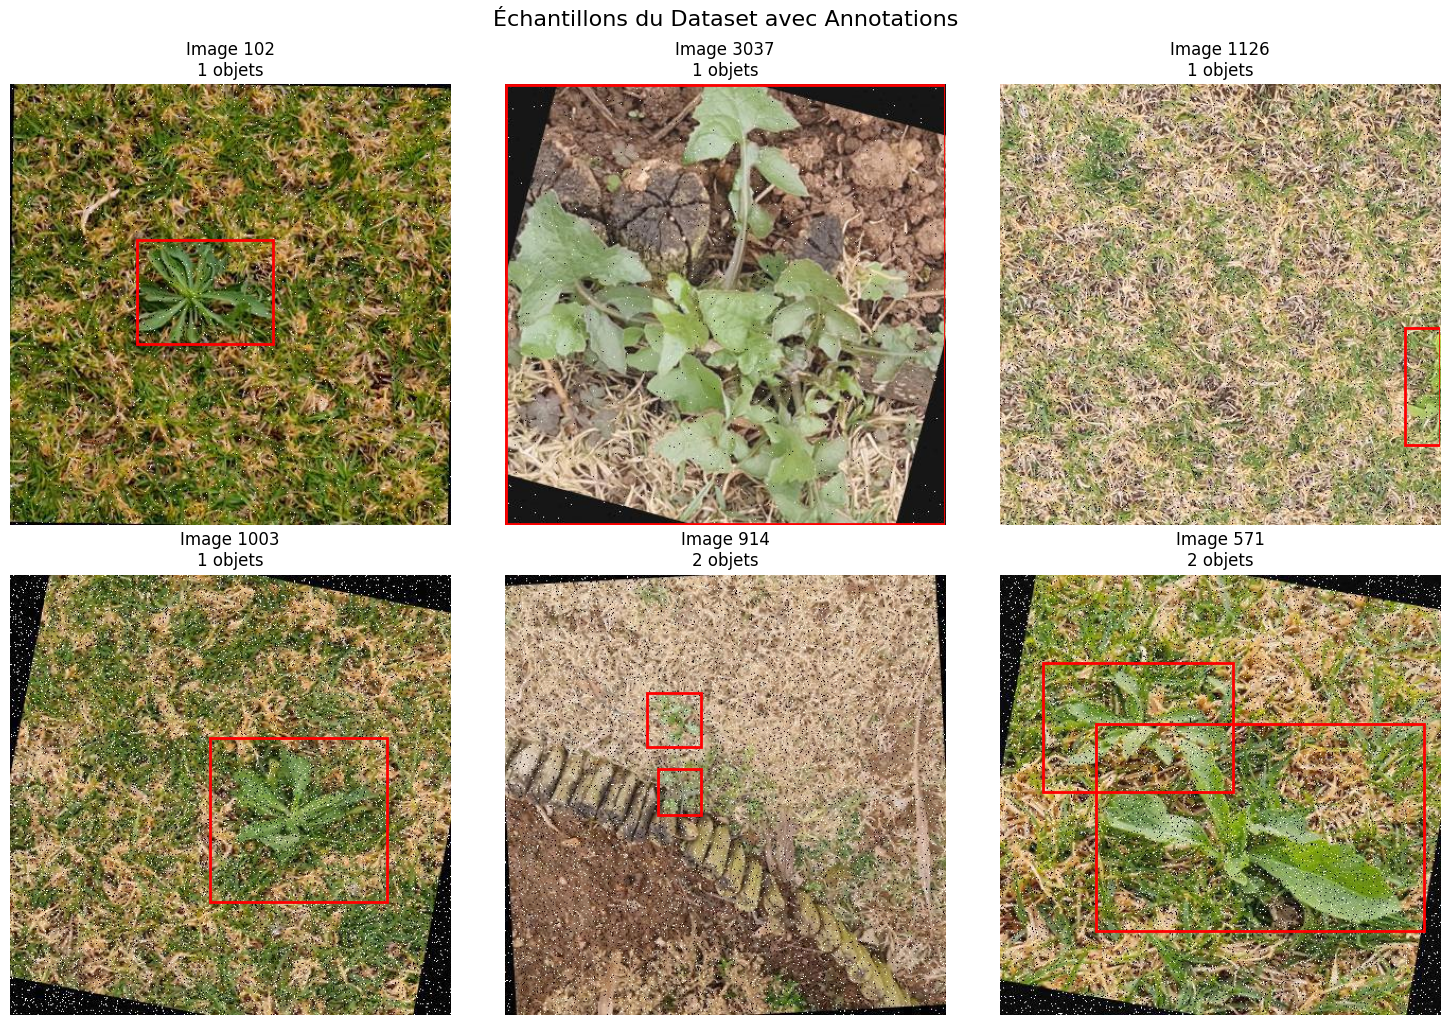

In [ ]:
def visualize_dataset_samples(dataset, num_samples=6):
    """Affiche des échantillons du dataset avec annotations"""

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()

    # Sélection d'échantillons aléatoires
    sample_indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))

    for idx, sample_idx in enumerate(sample_indices):
        image_path, image, annotations = dataset[sample_idx]

        # Conversion BGR vers RGB pour matplotlib
        if len(image.shape) == 3 and image.shape[2] == 3:
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        else:
            image_rgb = image

        axes[idx].imshow(image_rgb)
        axes[idx].set_title(f'Image {sample_idx}\n{len(annotations.xyxy) if annotations.xyxy is not None else 0} objets')
        axes[idx].axis('off')

        # Ajout des bounding boxes si disponibles
        if annotations.xyxy is not None:
            for bbox in annotations.xyxy:
                x1, y1, x2, y2 = bbox
                width, height = x2 - x1, y2 - y1
                rect = plt.Rectangle((x1, y1), width, height, linewidth=2,
                                   edgecolor='red', facecolor='none')
                axes[idx].add_patch(rect)

    plt.tight_layout()
    plt.suptitle('Échantillons du Dataset avec Annotations', fontsize=16, y=1.02)
    plt.show()

# Affichage des échantillons
visualize_dataset_samples(ds, num_samples=6)

In [ ]:
def analyze_dataset_quality(dataset_path):
    """Analyse la qualité et détecte les problèmes potentiels"""

    quality_report = {
        'corrupted_images': [],
        'missing_annotations': [],
        'empty_annotations': [],
        'image_sizes': [],
        'annotation_counts': []
    }

    # Analyse de chaque split
    for split in ['train', 'valid', 'test']:
        images_dir = f"{dataset_path}/{split}/images"
        labels_dir = f"{dataset_path}/{split}/labels"

        if not os.path.exists(images_dir):
            continue

        print(f"🔍 Analyse du split '{split}'...")

        image_files = [f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        for img_file in image_files[:50]:  # Limite pour éviter la lenteur
            img_path = os.path.join(images_dir, img_file)
            label_path = os.path.join(labels_dir, img_file.rsplit('.', 1)[0] + '.txt')

            # Vérification image
            try:
                img = cv2.imread(img_path)
                if img is None:
                    quality_report['corrupted_images'].append(img_path)
                    continue

                h, w = img.shape[:2]
                quality_report['image_sizes'].append((w, h))

            except Exception as e:
                quality_report['corrupted_images'].append(img_path)
                continue

            # Vérification annotation
            if not os.path.exists(label_path):
                quality_report['missing_annotations'].append(img_path)
            else:
                try:
                    with open(label_path, 'r') as f:
                        lines = f.readlines()

                    if len(lines) == 0:
                        quality_report['empty_annotations'].append(img_path)
                    else:
                        quality_report['annotation_counts'].append(len(lines))

                except Exception as e:
                    quality_report['missing_annotations'].append(img_path)

    return quality_report

# Analyse de qualité
print("🔍 Analyse de la qualité du dataset...")
quality_report = analyze_dataset_quality(DATASET_PATH)

print(f"\n📊 Rapport de qualité:")
print(f"   ❌ Images corrompues: {len(quality_report['corrupted_images'])}")
print(f"   📄 Annotations manquantes: {len(quality_report['missing_annotations'])}")
print(f"   📋 Annotations vides: {len(quality_report['empty_annotations'])}")

if quality_report['image_sizes']:
    sizes = np.array(quality_report['image_sizes'])
    print(f"   📏 Taille d'image moyenne: {sizes.mean(axis=0).astype(int)}")
    print(f"   📐 Taille min: {sizes.min(axis=0)}, max: {sizes.max(axis=0)}")

if quality_report['annotation_counts']:
    counts = quality_report['annotation_counts']
    print(f"   🎯 Objets par image: moy={np.mean(counts):.1f}, min={min(counts)}, max={max(counts)}")

🔍 Analyse de la qualité du dataset...
🔍 Analyse du split 'train'...
🔍 Analyse du split 'valid'...
🔍 Analyse du split 'test'...

📊 Rapport de qualité:
   ❌ Images corrompues: 0
   📄 Annotations manquantes: 0
   📋 Annotations vides: 0
   📏 Taille d'image moyenne: [416 416]
   📐 Taille min: [416 416], max: [416 416]
   🎯 Objets par image: moy=2.4, min=1, max=14


In [ ]:
# Configuration du modèle YOLOv12
MODEL_CONFIG = {
    'architecture': 'yolo11s.yaml',  # Small model pour équilibre vitesse/précision
    'pretrained': True,              # Utilise des poids pré-entraînés
    'task': 'detect'                 # Tâche de détection d'objets
}

print(f"🤖 Configuration du modèle:")
for key, value in MODEL_CONFIG.items():
    print(f"   {key}: {value}")

# Chargement du modèle
print(f"\n📥 Chargement du modèle {MODEL_CONFIG['architecture']}...")

try:
    model = YOLO(MODEL_CONFIG['architecture'])
    print(f"✅ Modèle chargé avec succès")

    # Affichage de l'architecture
    print(f"📊 Paramètres du modèle: {sum(p.numel() for p in model.model.parameters()):,}")

except Exception as e:
    print(f"❌ Erreur lors du chargement: {e}")
    # Fallback vers YOLOv11 si YOLOv12 non disponible
    print("🔄 Tentative avec YOLOv11...")
    model = YOLO('yolo11s.yaml')
    MODEL_CONFIG['architecture'] = 'yolo11s.yaml'

🤖 Configuration du modèle:
   architecture: yolo11s.yaml
   pretrained: True
   task: detect

📥 Chargement du modèle yolo11s.yaml...
✅ Modèle chargé avec succès
📊 Paramètres du modèle: 9,458,752


In [ ]:
# Configuration d'entraînement
TRAINING_CONFIG = {
    # Paramètres principaux
    'data': DATA_YAML_PATH,         # Chemin vers la configuration des données
    'epochs': 100,                  # Nombre d'époques d'entraînement
    'batch': 16,                   # Taille de batch (ajustez selon votre GPU)
    'imgsz': 640,                  # Taille d'image d'entrée

    # Optimisation
    'optimizer': 'AdamW',          # Optimiseur moderne et efficace
    'lr0': 0.01,                   # Learning rate initial
    'lrf': 0.1,                    # Learning rate final (lr0 * lrf)
    'momentum': 0.937,             # Momentum pour SGD
    'weight_decay': 0.0005,        # Régularisation L2

    # Augmentation des données
    'hsv_h': 0.015,               # Augmentation de teinte
    'hsv_s': 0.7,                 # Augmentation de saturation
    'hsv_v': 0.4,                 # Augmentation de luminosité
    'degrees': 0.0,               # Rotation (désactivée pour stabilité)
    'translate': 0.1,             # Translation
    'scale': 0.5,                 # Mise à l'échelle
    'shear': 0.0,                 # Cisaillement (désactivé)
    'perspective': 0.0,           # Perspective (désactivée)
    'flipud': 0.0,                # Flip vertical (inadapté pour ce dataset)
    'fliplr': 0.5,                # Flip horizontal
    'mosaic': 1.0,                # Augmentation mosaïque
    'mixup': 0.0,                 # Mixup (désactivé pour la détection)

    # Contrôle d'entraînement
    'patience': 50,               # Early stopping après 50 époques sans amélioration
    'save_period': 10,            # Sauvegarde tous les 10 époques
    'val': True,                  # Validation pendant l'entraînement
    'plots': True,                # Génération de graphiques
    'device': device,             # GPU ou CPU

    # Organisation des résultats
    'project': 'yolo_experiments', # Dossier principal des expériences
    'name': f'weed_detection_{MODEL_CONFIG["architecture"].split(".")[0]}', # Nom de l'expérience
    'exist_ok': True,             # Écrase les expériences existantes

    # Performance
    'workers': 8,                 # Nombre de workers pour le chargement des données
    'cache': True,                # Cache les images en RAM pour plus de vitesse
    'amp': True,                  # Mixed precision training (économise la mémoire)
    'verbose': True               # Affichage détaillé
}

print("⚙️  Configuration d'entraînement:")
print("📊 Paramètres principaux:")
for key in ['epochs', 'batch', 'imgsz', 'optimizer', 'lr0']:
    print(f"   {key}: {TRAINING_CONFIG[key]}")

print("\n🎨 Augmentation des données:")
for key in ['hsv_h', 'hsv_s', 'hsv_v', 'translate', 'scale', 'fliplr']:
    print(f"   {key}: {TRAINING_CONFIG[key]}")

print(f"\n💾 Sauvegarde: {TRAINING_CONFIG['project']}/{TRAINING_CONFIG['name']}")

⚙️  Configuration d'entraînement:
📊 Paramètres principaux:
   epochs: 100
   batch: 16
   imgsz: 640
   optimizer: AdamW
   lr0: 0.01

🎨 Augmentation des données:
   hsv_h: 0.015
   hsv_s: 0.7
   hsv_v: 0.4
   translate: 0.1
   scale: 0.5
   fliplr: 0.5

💾 Sauvegarde: yolo_experiments/weed_detection_yolo11s


In [ ]:
# Test rapide avant l'entraînement complet
print("🧪 Test préliminaire du modèle...")

try:
    # Validation initiale pour s'assurer que tout fonctionne
    initial_metrics = model.val(
        data=DATA_YAML_PATH,
        batch=4,  # Batch réduit pour le test
        device=device,
        verbose=False
    )

    print(f"✅ Test préliminaire réussi")
    print(f"   📊 mAP50 initial: {initial_metrics.box.map50:.4f}")
    print(f"   📊 mAP50-95 initial: {initial_metrics.box.map:.4f}")

except Exception as e:
    print(f"❌ Erreur lors du test: {e}")
    print("🔧 Vérifiez la configuration des données et chemins")
    raise

🧪 Test préliminaire du modèle...
Ultralytics 8.3.147 🚀 Python-3.11.12 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
YOLO11s summary (fused): 100 layers, 9,443,760 parameters, 43,440 gradients, 21.5 GFLOPs


100%|██████████| 755k/755k [00:00<00:00, 18.3MB/s]

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 744.9±440.8 MB/s, size: 59.1 KB)



val: Scanning /content/Weeds-3/valid/labels... 359 images, 0 backgrounds, 0 corrupt: 100%|██████████| 359/359 [00:00<00:00, 1828.27it/s]


val: New cache created: /content/Weeds-3/valid/labels.cache


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 90/90 [03:47<00:00,  2.53s/it]


                   all        359        920          0          0          0          0
Speed: 2.2ms preprocess, 621.5ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to runs/detect/val
✅ Test préliminaire réussi
   📊 mAP50 initial: 0.0000
   📊 mAP50-95 initial: 0.0000


In [ ]:
import time
# 🔧 Chemin vers le fichier data.yaml
DATA_YAML_PATH = "/content/Weeds-3/data.yaml"

import torch
import os
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🖥️  Device utilisé: {device}")
if device == 'cpu':
    print("⚠️  CPU uniquement - L'entraînement sera plus lent")
MODEL_CONFIG = {
    "architecture": "yolo11n.pt"
}
from ultralytics import YOLO
import matplotlib.pyplot as plt
model = YOLO('yolo11n.pt')
TRAINING_CONFIG = {
    # Paramètres principaux
    'data': DATA_YAML_PATH,         # Chemin vers la configuration des données
    'epochs': 100,                  # Nombre d'époques d'entraînement
    'batch': 16,                   # Taille de batch (ajustez selon votre GPU)
    'imgsz': 640,                  # Taille d'image d'entrée

    # Optimisation
    'optimizer': 'AdamW',          # Optimiseur moderne et efficace
    'lr0': 0.01,                   # Learning rate initial
    'lrf': 0.1,                    # Learning rate final (lr0 * lrf)
    'momentum': 0.937,             # Momentum pour SGD
    'weight_decay': 0.0005,        # Régularisation L2

    # Augmentation des données
    'hsv_h': 0.015,               # Augmentation de teinte
    'hsv_s': 0.7,                 # Augmentation de saturation
    'hsv_v': 0.4,                 # Augmentation de luminosité
    'degrees': 0.0,               # Rotation (désactivée pour stabilité)
    'translate': 0.1,             # Translation
    'scale': 0.5,                 # Mise à l'échelle
    'shear': 0.0,                 # Cisaillement (désactivé)
    'perspective': 0.0,           # Perspective (désactivée)
    'flipud': 0.0,                # Flip vertical (inadapté pour ce dataset)
    'fliplr': 0.5,                # Flip horizontal
    'mosaic': 1.0,                # Augmentation mosaïque
    'mixup': 0.0,                 # Mixup (désactivé pour la détection)

    # Contrôle d'entraînement
    'patience': 50,               # Early stopping après 50 époques sans amélioration
    'save_period': 10,            # Sauvegarde tous les 10 époques
    'val': True,                  # Validation pendant l'entraînement
    'plots': True,                # Génération de graphiques
    'device': device,             # GPU ou CPU

    # Organisation des résultats
    'project': 'yolo_experiments', # Dossier principal des expériences
    'name': f'weed_detection_{MODEL_CONFIG["architecture"].split(".")[0]}', # Nom de l'expérience
    'exist_ok': True,             # Écrase les expériences existantes

    # Performance
    'workers': 8,                 # Nombre de workers pour le chargement des données
    'cache': True,                # Cache les images en RAM pour plus de vitesse
    'amp': True,                  # Mixed precision training (économise la mémoire)
    'verbose': True               # Affichage détaillé
}
print("🚀 Démarrage de l'entraînement...")
print(f"   🕐 Heure de début: {time.strftime('%H:%M:%S')}")

# Sauvegarde de la configuration pour reproductibilité
# 5. Entraînement du Modèle
# 5.1 Pré-validation du Modèle

import json
config_save_path = f"{TRAINING_CONFIG['project']}/{TRAINING_CONFIG['name']}/config.json"
os.makedirs(os.path.dirname(config_save_path), exist_ok=True)

with open(config_save_path, 'w') as f:
    # Conversion des objets non-sérialisables
    config_to_save = TRAINING_CONFIG.copy()
    config_to_save['device'] = str(config_to_save['device'])
    json.dump(config_to_save, f, indent=2)

print(f"💾 Configuration sauvegardée: {config_save_path}")

# ENTRAÎNEMENT PRINCIPAL
start_time = time.time()

try:
    results = model.train(**TRAINING_CONFIG)

    training_time = time.time() - start_time
    print(f"\n🎉 Entraînement terminé!")
    print(f"   ⏱️  Durée totale: {training_time/3600:.1f} heures")
    print(f"   📁 Résultats sauvés: {results.save_dir}")

except Exception as e:
    print(f"\n❌ Erreur pendant l'entraînement:")
    print(f"   {str(e)}")

    # Suggestions de débogage
    print(f"\n🔧 Suggestions de débogage:")
    print(f"   - Réduire batch_size si erreur de mémoire")
    print(f"   - Vérifier les chemins dans data.yaml")
    print(f"   - Contrôler l'espace disque disponible")

    raise


# 5.3 Monitoring en Temps Réel (Optionnel)

# Monitoring pendant l'entraînement (exécuter dans une autre cellule)
def monitor_training_progress(results_dir, refresh_interval=30):
    """
    Affiche les métriques d'entraînement en temps réel

    Args:
        results_dir: Dossier contenant results.csv
        refresh_interval: Intervalle de mise à jour en secondes
    """
    import pandas as pd
    import time
    from IPython.display import clear_output

    results_file = os.path.join(results_dir, 'results.csv')

    while True:
        try:
            clear_output(wait=True)

            if os.path.exists(results_file):
                df = pd.read_csv(results_file)

                if len(df) > 0:
                    latest = df.iloc[-1]

                    print(f"📊 Progression de l'entraînement (Époque {latest['epoch']}/{TRAINING_CONFIG['epochs']})")
                    print(f"   📈 mAP50: {latest['metrics/mAP50(B)']:.4f}")
                    print(f"   📉 Train Loss: {latest['train/box_loss']:.4f}")
                    print(f"   📉 Val Loss: {latest['val/box_loss']:.4f}")

                    # Graphique simple
                    if len(df) > 5:
                        plt.figure(figsize=(12, 4))

                        plt.subplot(1, 2, 1)
                        plt.plot(df['epoch'], df['train/box_loss'], label='Train Loss')
                        plt.plot(df['epoch'], df['val/box_loss'], label='Val Loss')
                        plt.xlabel('Époque')
                        plt.ylabel('Loss')
                        plt.legend()
                        plt.title('Évolution des Losses')

                        plt.subplot(1, 2, 2)
                        plt.plot(df['epoch'], df['metrics/mAP50(B)'], 'g-', label='mAP@0.5')
                        plt.xlabel('Époque')
                        plt.ylabel('mAP@0.5')
                        plt.legend()
                        plt.title('Évolution de la Précision')

                        plt.tight_layout()
                        plt.show()
                else:
                    print("⏳ En attente du début de l'entraînement...")
            else:
                print("⏳ Fichier de résultats non trouvé, en attente...")

            time.sleep(refresh_interval)

        except KeyboardInterrupt:
            print("🛑 Monitoring arrêté")
            break
        except Exception as e:
            print(f"⚠️  Erreur de monitoring: {e}")
            time.sleep(refresh_interval)

# Utilisation (décommentez pour activer):
monitor_training_progress(f"{TRAINING_CONFIG['project']}/{TRAINING_CONFIG['name']}")